In [80]:
from src.dataset import load_dataset
from polynomial_regression import PolynomialRegression
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [81]:
TRAIN_PATH_X = "../../data/processed/train/train.csv"
RESIDUI_PATH = "../../output/polynomial_regression/residui/residui.csv"
ITERATIONS = 1000
TARGET_COL = "trq_target"
DEGREE = 3

In [83]:
train_data = pd.read_csv(TRAIN_PATH_X)
drop_cols = [TARGET_COL]
X_cols = [c for c in train_data.columns if c not in drop_cols]
X_train = train_data[X_cols].values
y_train = train_data[TARGET_COL].values
model = PolynomialRegression(degree=DEGREE)
model.fit(X_train, y_train)

In [35]:
yhat_train = model.predict(X_train)
residui=pd.DataFrame({
    "residui": y_train-yhat_train,
    "yhat_train": yhat_train,
    "y_train": y_train,
})


ciao


,residui,yhat_train,y_train
0,-0.006991,62.708181,62.701189
1,-0.004559,48.756000,48.751441
2,0.022184,60.404197,60.426381
3,-0.012919,62.423704,62.410785
4,0.009809,58.598644,58.608452


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_train, yhat_train)
mse  = mean_squared_error(y_train, yhat_train)
rmse = np.sqrt(mse)

print(f"MAE  (train): {mae:.4f}")
print(f"MSE  (train): {mse:.4f}")
print(f"RMSE (train): {rmse:.4f}")

r2 = r2_score(y_train, yhat_train)

n = len(y_train)
p = model.poly.n_output_features_

r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R² (train): {r2:.4f}")
print(f"R² adj (train): {r2_adj:.4f}")

MAE  (train): 0.0170
MSE  (train): 0.0008
RMSE (train): 0.0282
R² (train): 1.0000
R² adj (train): 1.0000


In [55]:
residui=load_dataset(RESIDUI_PATH)
distribuistion_target=pd.DataFrame(columns=[TARGET_COL])
target=62.708181
mesured=54.1
trq_margin=-13.727
for i in range(ITERATIONS):
    residuo = residui["residui"].sample().iloc[0]
    distribuistion_target.loc[len(distribuistion_target)]=target+residuo

distribuistion_target['trq_margin'] =((mesured-distribuistion_target['trq_target'])/(distribuistion_target['trq_target']))*100
distribuistion_target.head()

,trq_target,trq_margin
0,62.658983,-13.659626
1,62.701139,-13.717675
2,62.707193,-13.726006
3,62.709723,-13.729487
4,62.684292,-13.694487


In [78]:
from scipy.stats import uniform, beta, norm, cauchy

# ===== INPUT =====
T_hat_margin = -13.727-0.5  # oppure metti direttamente il numero: 62.708181

# ===== PARAMETRI come da tabella =====
# 1) Uniforme
u_loc = T_hat_margin-0.5
u_scale = 1

# 2) Beta
a, b_ = 1.5, 1.5
beta_loc = T_hat_margin - 0.6365
beta_scale = 1.273

# 3) Normale
# Qui c'è ambiguità: tu hai scritto scale = 1/√(2π) (se intendevi la radice) oppure 1/(2π).
# Scelgo l'interpretazione più comune: 1/sqrt(2*pi)
normal_scale = 1 / np.sqrt(2*np.pi)   # ≈ 0.3989
# Se invece intendevi 1/(2*pi), usa questa:
# normal_scale = 1 / (2*np.pi)        # ≈ 0.1592

# 4) Cauchy
cauchy_scale = 1 / np.pi              # ≈ 0.3183

# ===== GRIGLIA X (scegli un range abbastanza ampio, soprattutto per Cauchy) =====
x = np.linspace(T_hat_margin - 5, T_hat_margin + 5, 2000)

# ===== PDF =====
pdf_uniform = uniform.pdf(x, loc=u_loc, scale=u_scale)
pdf_beta = beta.pdf(x, a=a, b=b_, loc=beta_loc, scale=beta_scale)
pdf_normal = norm.pdf(x, loc=T_hat_margin, scale=normal_scale)
pdf_cauchy = cauchy.pdf(x, loc=T_hat_margin, scale=cauchy_scale)

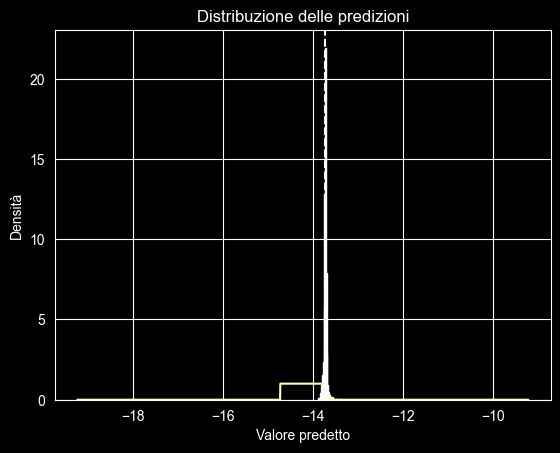

In [79]:
from random import uniform
plt.figure()
plt.hist(distribuistion_target["trq_margin"], bins=30, density=True)
plt.plot(x, pdf_uniform, label="Uniforme")
plt.axvline(-13.727, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()